La descripción del contexto y la procedencia del dataset: qué mide, quién lo recolectó, cuándo, y cuál es la unidad de observación.

La verificación de la estructura: dimensiones y tipo de cada atributo, incluyendo una celda inicial que compruebe el cumplimiento de los requisitos anteriores.

El análisis de la calidad de los datos: patrón de valores faltantes, duplicados, valores imposibles, y cardinalidad de los atributos categóricos.

El análisis univariado: distribución y estadísticos descriptivos de los atributos relevantes.

El análisis bivariado: relaciones entre pares de atributos, justificando cuáles se exploran y por qué.

Al menos una vista multivariada, e.g., matriz de correlación, matriz de dispersión, o el uso del color como tercera dimensión.

La interpretación escrita de cada figura: qué se observa y qué implica. No se aceptan gráficas sin lectura.

Un cierre con al menos tres hallazgos, las preguntas que abre el dataset, y los problemas que requerirían corrección antes de cualquier análisis posterior.


no se si es necesario, pero, al revisar los dataset que usarlo en mentalbert(creo) eran 3 datasets los cuales incluian solamente el corpus con el que se iba a trabajar, y yo quise tener un poquito mas de datos extra que tal vez puedan ayudar a que nos demos cuenta que esta pasando aparte del texto, por ejemplo tal vez la cantidad de mayusculas y signos de interrogacion puedan tener un valor sentimental que no se ve a simple vista o que un modelo como textblob no lo entienda por no estar en el lexicon. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data Loading & Overview

In [2]:
df = pd.read_csv("dataset/output/asktransgender_dataset.csv")

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

df['type'].value_counts()

Shape: 66659 rows x 23 columns

Columns: ['type', 'title', 'text', 'score', 'upvote_ratio', 'num_comments', 'created_utc', 'text_length', 'word_count', 'question_mark_count', 'exclamation_mark_count', 'sentiment_score', 'sentiment_subjectivity', 'avg_word_length', 'unique_word_ratio', 'uppercase_ratio', 'punctuation_count', 'has_url', 'has_mention', 'has_suggested_subreddit', 'suggested_subreddit', 'has_emoji', 'caps_words_count']

First 3 rows:


type
comment       65778
submission      881
Name: count, dtype: int64

In [3]:
df.dtypes

type                           str
title                          str
text                           str
score                        int64
upvote_ratio               float64
num_comments               float64
created_utc                float64
text_length                  int64
word_count                   int64
question_mark_count          int64
exclamation_mark_count       int64
sentiment_score            float64
sentiment_subjectivity     float64
avg_word_length            float64
unique_word_ratio          float64
uppercase_ratio            float64
punctuation_count            int64
has_url                      int64
has_mention                  int64
has_suggested_subreddit      int64
suggested_subreddit            str
has_emoji                    int64
caps_words_count             int64
dtype: object

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
score,66659.0,2.757653e+01,1.417621e+02,-2.550000e+02,1.000000e+00,3.000000e+00,1.200000e+01,4.915000e+03
upvote_ratio,881.0,9.100681e-01,1.630804e-01,6.000000e-02,9.200000e-01,9.800000e-01,1.000000e+00,1.000000e+00
num_comments,881.0,7.457889e+01,9.478959e+01,0.000000e+00,5.000000e+00,2.900000e+01,1.220000e+02,6.910000e+02
created_utc,66659.0,1.649645e+09,7.066287e+07,1.497511e+09,1.598319e+09,1.625802e+09,1.686496e+09,1.789167e+09
text_length,66659.0,3.094453e+02,4.850876e+02,0.000000e+00,6.400000e+01,1.610000e+02,3.670000e+02,2.121100e+04
word_count,66659.0,5.531286e+01,8.472914e+01,0.000000e+00,1.100000e+01,2.900000e+01,6.600000e+01,2.189000e+03
question_mark_count,66659.0,2.561545e-01,7.958453e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.300000e+01
exclamation_mark_count,66659.0,2.028683e-01,7.624433e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.600000e+01
sentiment_score,66659.0,8.986118e-02,2.554625e-01,-1.000000e+00,0.000000e+00,4.109247e-02,2.052016e-01,1.000000e+00
sentiment_subjectivity,66659.0,4.432238e-01,2.797835e-01,0.000000e+00,2.666667e-01,4.928571e-01,6.203704e-01,1.000000e+00


In [5]:
print("Missing values:")
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("  None found")
else:
    print(missing.to_string())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
title           65778
text               44
upvote_ratio    65778
num_comments    65778

Duplicate rows: 3


## 2. Temporal Analysis

Analyzing how posting frequency and engagement evolved over time.

In [6]:
df['created_date'] = pd.to_datetime(df['created_utc'], unit='s')
df['year'] = df['created_date'].dt.year
df['month'] = df['created_date'].dt.month
df['day_of_week'] = df['created_date'].dt.day_name()

print(f"Date range: {df['created_date'].min().date()} to {df['created_date'].max().date()}")
print(f"Total span: {df['created_date'].max() - df['created_date'].min()}")

Date range: 2017-06-15 to 2026-09-11
Total span: 3375 days 15:36:57


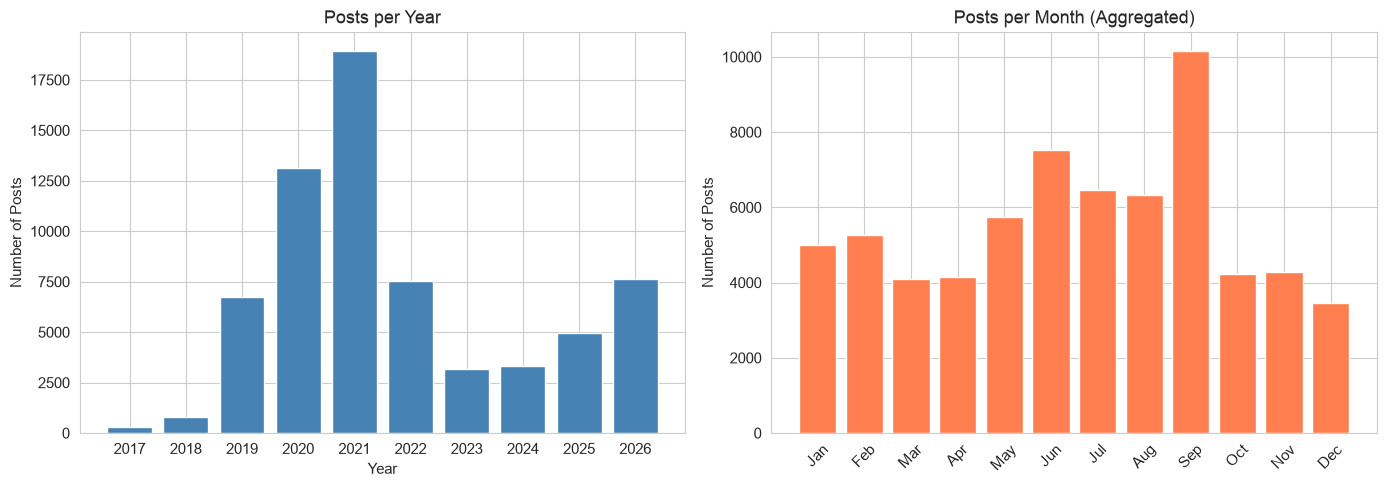

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly = df.groupby('year').size()
axes[0].bar(yearly.index.astype(str), yearly.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Posts')
axes[0].set_title('Posts per Year')

monthly = df.groupby('month').size()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(range(12), monthly.reindex(range(1,13)).values, color='coral', edgecolor='white')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_names, rotation=45)
axes[1].set_ylabel('Number of Posts')
axes[1].set_title('Posts per Month (Aggregated)')

plt.tight_layout()
plt.show()

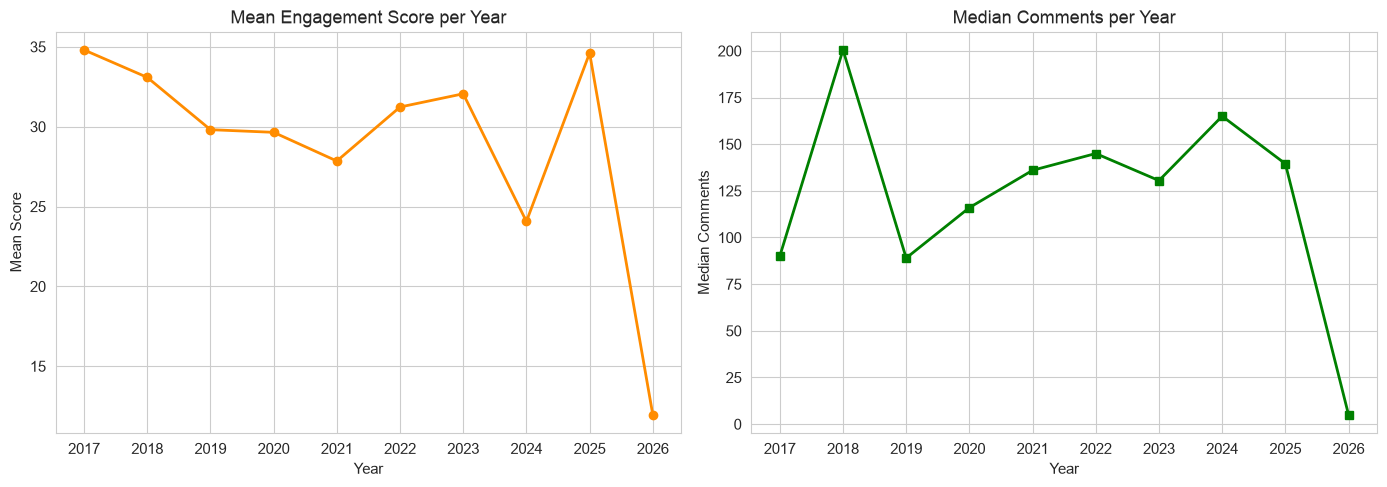

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly_score = df.groupby('year')['score'].mean()
axes[0].plot(yearly_score.index.astype(str), yearly_score.values, 'o-', color='darkorange', linewidth=2)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Score')
axes[0].set_title('Mean Engagement Score per Year')

yearly_comments = df.groupby('year')['num_comments'].median()
axes[1].plot(yearly_comments.index.astype(str), yearly_comments.values, 's-', color='green', linewidth=2)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Comments')
axes[1].set_title('Median Comments per Year')

plt.tight_layout()
plt.show()

## 3. Text Feature Distributions

Examining the distribution of text-derived features to understand post characteristics and identify potential data artifacts.

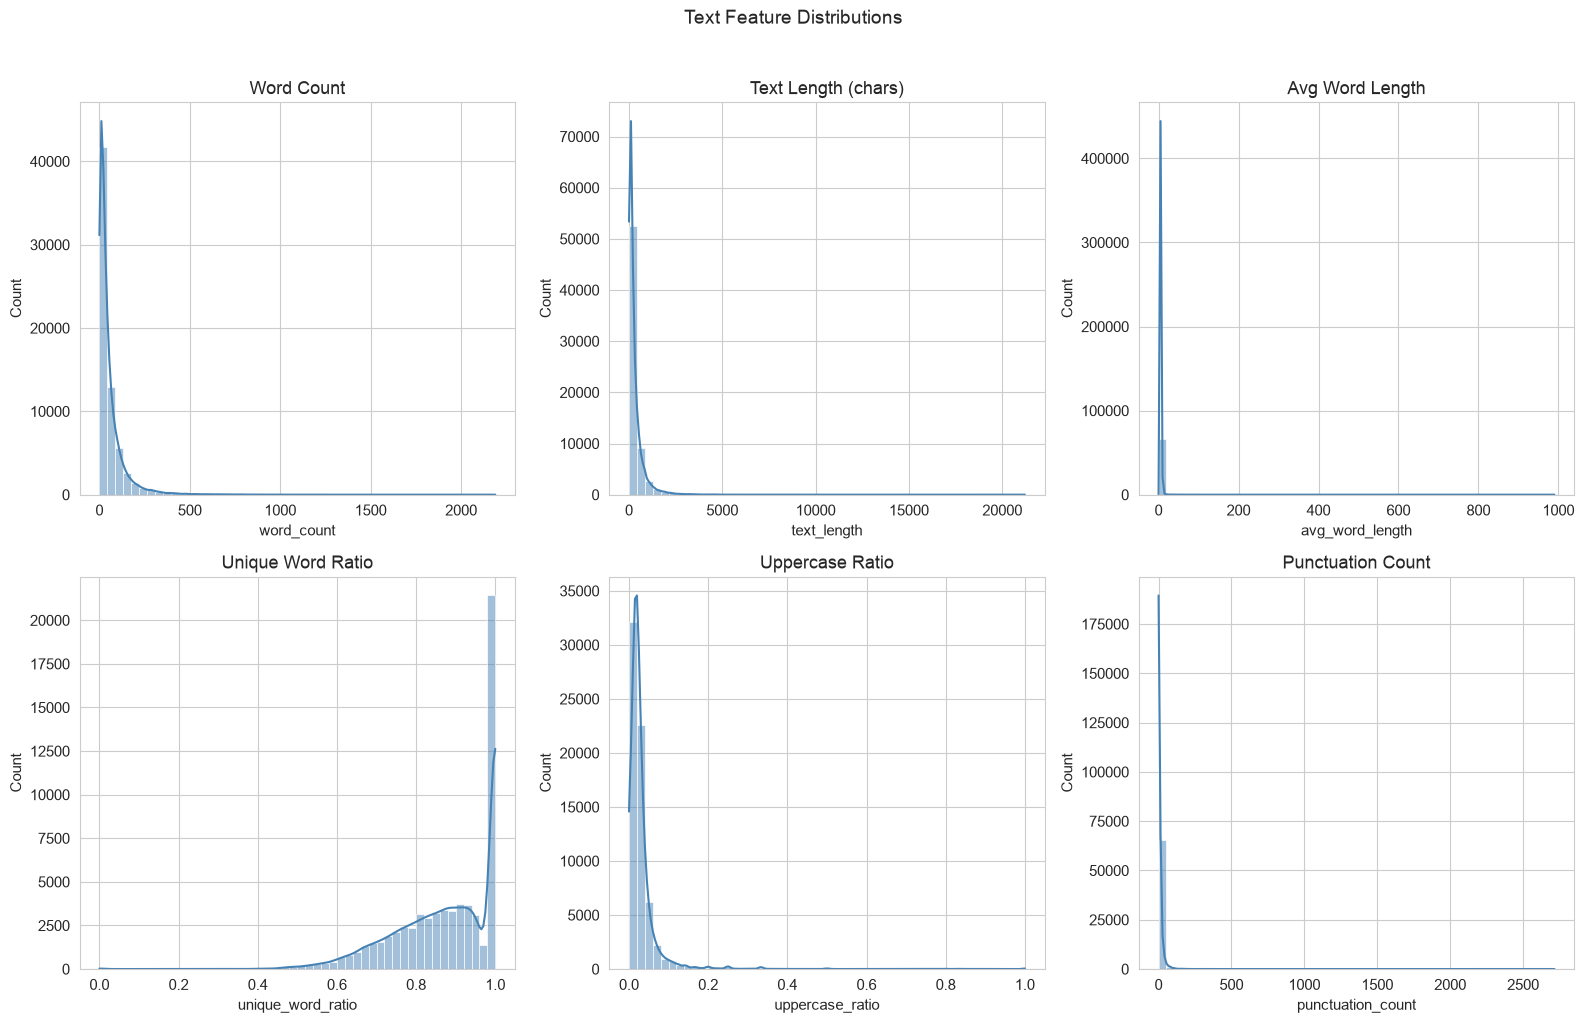

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features = ['word_count', 'text_length', 'avg_word_length', 'unique_word_ratio', 'uppercase_ratio', 'punctuation_count']
titles = ['Word Count', 'Text Length (chars)', 'Avg Word Length', 'Unique Word Ratio', 'Uppercase Ratio', 'Punctuation Count']

for ax, feat, title in zip(axes.flat, features, titles):
    sns.histplot(df[feat], bins=50, ax=ax, kde=True, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel(feat)

plt.suptitle('Text Feature Distributions', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

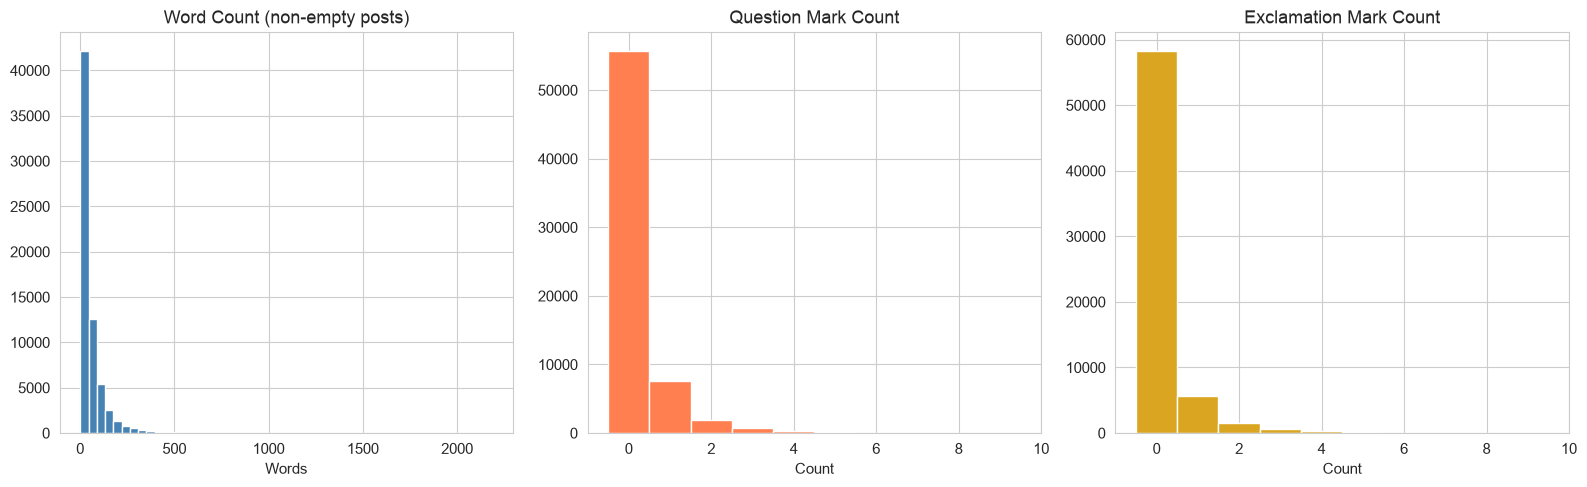

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Word count (no vacíos)
axes[0].hist(df.loc[df['text'].notna() & (df['text'] != ''), 'word_count'],
             bins=50, color='steelblue')
axes[0].set_title('Word Count (non-empty posts)')
axes[0].set_xlabel('Words')

# Question marks (mismo filtro para comparabilidad)
mask = df['text'].notna() & (df['text'] != '')
axes[1].hist(df.loc[mask, 'question_mark_count'],
             bins=range(0, 11), color='coral', align='left')
axes[1].set_title('Question Mark Count')
axes[1].set_xlabel('Count')

# Exclamation marks
axes[2].hist(df.loc[mask, 'exclamation_mark_count'],
             bins=range(0, 11), color='goldenrod', align='left')
axes[2].set_title('Exclamation Mark Count')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 4. Sentiment Analysis

Exploring the distribution of sentiment scores (textblob) and their relationship with other features.

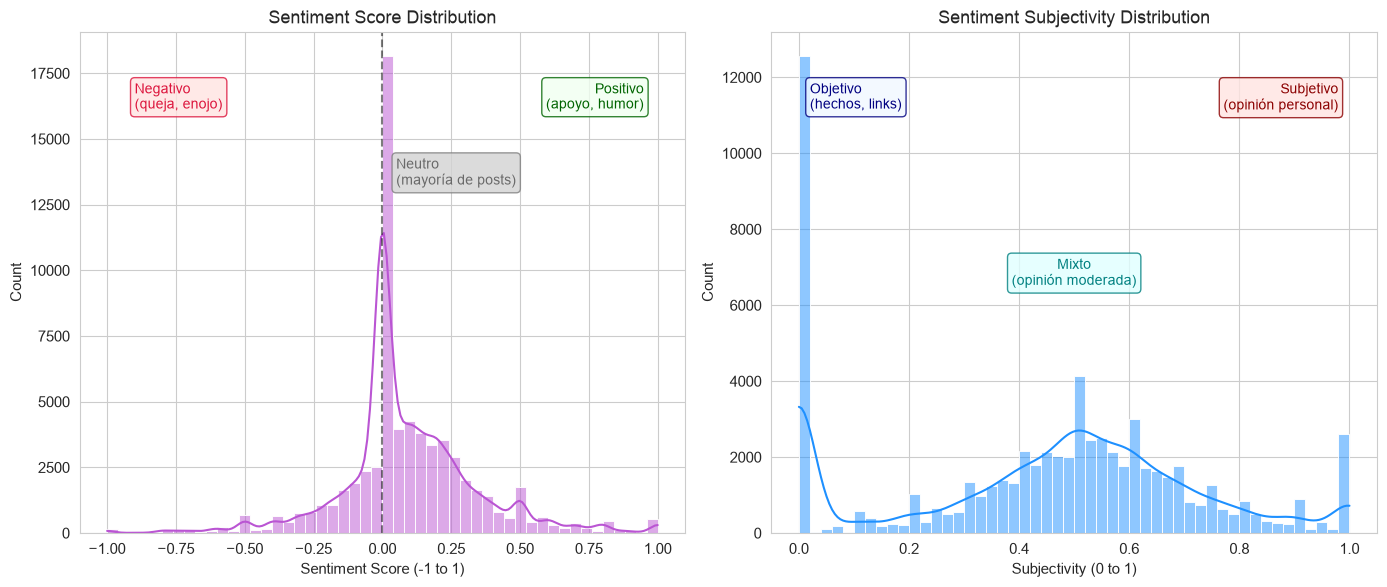

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Panel izquierdo: polaridad ----
sns.histplot(df['sentiment_score'], bins=50, kde=True, ax=axes[0], color='mediumorchid')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('Sentiment Score Distribution')
axes[0].set_xlabel('Sentiment Score (-1 to 1)')

# Anotaciones de zonas
axes[0].text(-0.9, axes[0].get_ylim()[1]*0.9, 'Negativo\n(queja, enojo)',
             color='crimson', fontsize=10, ha='left', va='top',
             bbox=dict(boxstyle='round,pad=0.3', fc='mistyrose', ec='crimson', alpha=0.8))
axes[0].text(0.05, axes[0].get_ylim()[1]*0.75, 'Neutro\n(mayoría de posts)',
             color='dimgray', fontsize=10, ha='left', va='top',
             bbox=dict(boxstyle='round,pad=0.3', fc='lightgray', ec='gray', alpha=0.8))
axes[0].text(0.95, axes[0].get_ylim()[1]*0.9, 'Positivo\n(apoyo, humor)',
             color='darkgreen', fontsize=10, ha='right', va='top',
             bbox=dict(boxstyle='round,pad=0.3', fc='honeydew', ec='darkgreen', alpha=0.8))

# ---- Panel derecho: subjetividad ----
sns.histplot(df['sentiment_subjectivity'], bins=50, kde=True, ax=axes[1], color='dodgerblue')
axes[1].set_title('Sentiment Subjectivity Distribution')
axes[1].set_xlabel('Subjectivity (0 to 1)')

axes[1].text(0.02, axes[1].get_ylim()[1]*0.9, 'Objetivo\n(hechos, links)',
             color='navy', fontsize=10, ha='left', va='top',
             bbox=dict(boxstyle='round,pad=0.3', fc='aliceblue', ec='navy', alpha=0.8))
axes[1].text(0.5, axes[1].get_ylim()[1]*0.55, 'Mixto\n(opinión moderada)',
             color='teal', fontsize=10, ha='center', va='top',
             bbox=dict(boxstyle='round,pad=0.3', fc='lightcyan', ec='teal', alpha=0.8))
axes[1].text(0.98, axes[1].get_ylim()[1]*0.9, 'Subjetivo\n(opinión personal)',
             color='darkred', fontsize=10, ha='right', va='top',
             bbox=dict(boxstyle='round,pad=0.3', fc='mistyrose', ec='darkred', alpha=0.8))

plt.tight_layout()
plt.show()

In [12]:
# Ver si el patrón es realmente: submission, comment, comment, ..., submission, comment...
print(df['type'].head(30).tolist())
print("\n¿Hay submissions consecutivas?")
print((df['type'] == 'submission').sum())
print((df['type'] == 'comment').sum())

['submission', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment', 'comment']

¿Hay submissions consecutivas?
881
65778


In [13]:
# Asignar submission_id por orden de aparición
submission_ids = []
current_sub = None
counter = 0

for t in df['type']:
    if t == 'submission':
        counter += 1
        current_sub = counter
    submission_ids.append(current_sub)

df['submission_id'] = submission_ids

# Verificar: cada submission debe tener al menos 1 comment (excepto quizá la última)
check = df.groupby('submission_id')['type'].apply(lambda x: (x == 'submission').sum())
print("Submissions por grupo (debe ser 1 en todos):")
print(check.value_counts())

Submissions por grupo (debe ser 1 en todos):
type
1    881
Name: count, dtype: int64


In [30]:
subs = df_temp[df_temp['type'] == 'submission'][
    ['submission_id', 'sentiment_score']
].rename(columns={
    'sentiment_score': 'sub_sentiment_score'
})

comments = df_temp[df_temp['type'] == 'comment'][
    ['submission_id', 'sentiment_score', 'score']
].rename(columns={
    'sentiment_score': 'com_sentiment_score',
    'score': 'com_score'
})

merged = comments.merge(subs, on='submission_id', how='left')
print(f"Comments con submission asignada: {merged['sub_sentiment_score'].notna().sum()} / {len(merged)}")

Comments con submission asignada: 65778 / 65778


In [32]:
merged['sub_sentiment_bin'] = pd.cut(
    merged['sub_sentiment_score'],
    bins=[-1, -0.05, 0.05, 1],
    labels=['negative', 'neutral', 'positive']
)

summary = merged.groupby('sub_sentiment_bin')['com_sentiment_score'].agg(
    ['mean', 'median', 'std', 'count']
).round(3)

print(summary)

                    mean  median    std  count
sub_sentiment_bin                             
negative           0.061   0.012  0.249  11558
neutral            0.071   0.011  0.248  19502
positive           0.110   0.062  0.262  34718


/var/folders/bg/cpfr08ss4blg9k1_jk8bvf480000gn/T/ipykernel_65824/107388031.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


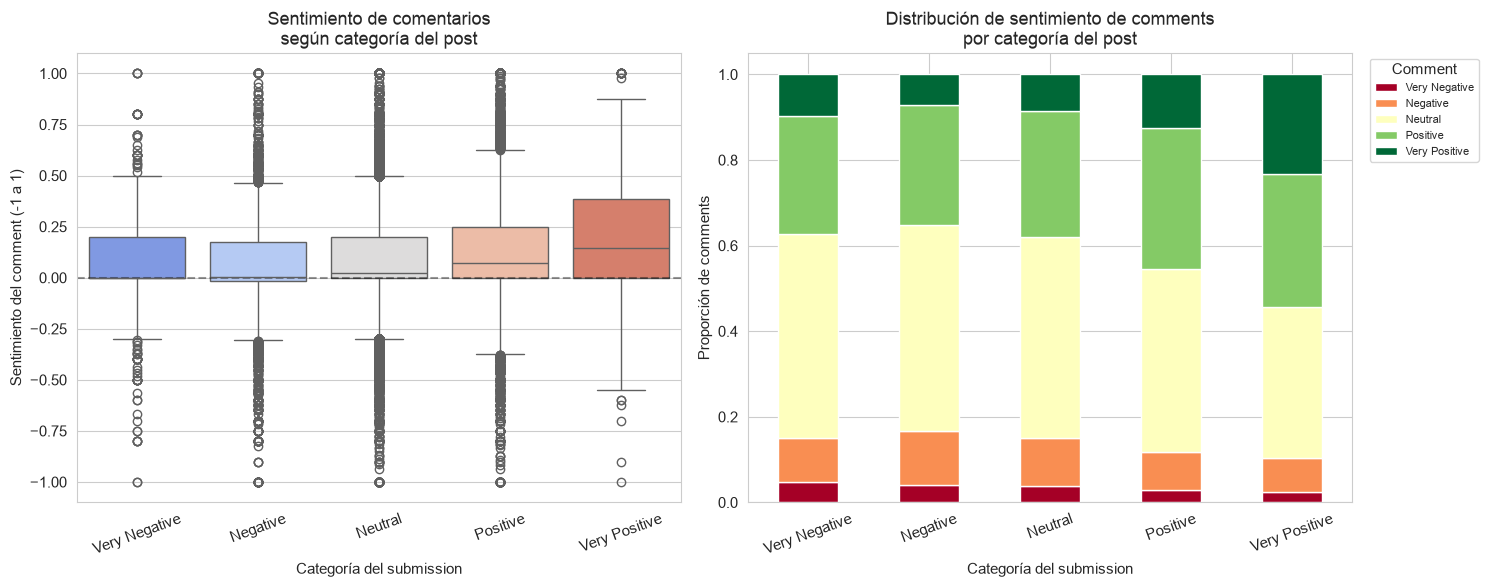

In [34]:
# --- Creamos las etiquetas categóricas con pd.cut (Opción B) ---
bins = [-1.0, -0.4, -0.1, 0.1, 0.4, 1.0]
labels = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']

# Para submissions
if 'sub_sentiment_label' not in merged.columns:
    merged['sub_sentiment_label'] = pd.cut(
        merged['sub_sentiment_score'],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

# Para comments
if 'com_sentiment_label' not in merged.columns:
    merged['com_sentiment_label'] = pd.cut(
        merged['com_sentiment_score'],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

order = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel 1: Boxplot de sentimiento de comments por categoría de submission ---
sns.boxplot(
    data=merged,
    x='sub_sentiment_label', y='com_sentiment_score',
    order=order, palette='coolwarm', ax=axes[0]
)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.4)
axes[0].set_title('Sentimiento de comentarios\nsegún categoría del post')
axes[0].set_xlabel('Categoría del submission')
axes[0].set_ylabel('Sentimiento del comment (-1 a 1)')
axes[0].tick_params(axis='x', rotation=20)

# --- Panel 2: Distribución (%) de categorías de comments por categoría de submission ---
cross = pd.crosstab(
    merged['sub_sentiment_label'],
    merged['com_sentiment_label'],
    normalize='index'
)
cross = cross.reindex(index=order, columns=order)

cross.plot(
    kind='bar', stacked=True, ax=axes[1],
    colormap='RdYlGn', edgecolor='white'
)
axes[1].set_title('Distribución de sentimiento de comments\npor categoría del post')
axes[1].set_xlabel('Categoría del submission')
axes[1].set_ylabel('Proporción de comments')
axes[1].legend(title='Comment', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

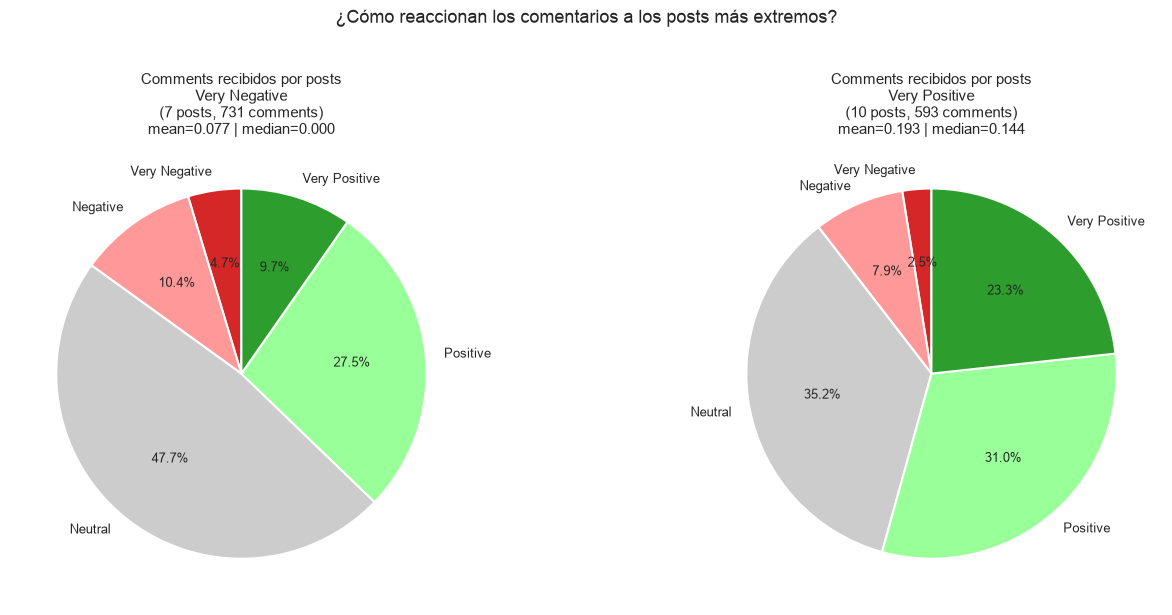

In [35]:
# Foco en los extremos
vn = merged[merged['sub_sentiment_label'] == 'Very Negative']
vp = merged[merged['sub_sentiment_label'] == 'Very Positive']

order = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']
colors = ['#d62728', '#ff9999', '#cccccc', '#99ff99', '#2d9e2d']
color_map = dict(zip(order, colors))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, subset, title in zip(
    axes,
    [vn, vp],
    ['Comments recibidos por posts\nVery Negative',
     'Comments recibidos por posts\nVery Positive']
):
    counts = subset['com_sentiment_label'].value_counts().reindex(order).fillna(0)
    counts = counts[counts > 0]  # solo categorías presentes
    pie_colors = [color_map[c] for c in counts.index]

    n_sub = subset['submission_id'].nunique()
    n_com = len(subset)
    mean_s = subset['com_sentiment_score'].mean()
    med_s  = subset['com_sentiment_score'].median()

    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=pie_colors,
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
        textprops=dict(fontsize=9)
    )
    ax.set_title(
        f"{title}\n"
        f"({n_sub} posts, {n_com} comments)\n"
        f"mean={mean_s:.3f} | median={med_s:.3f}",
        fontsize=11
    )

plt.suptitle('¿Cómo reaccionan los comentarios a los posts más extremos?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

/var/folders/bg/cpfr08ss4blg9k1_jk8bvf480000gn/T/ipykernel_65824/1973163472.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment_label', y='sentiment_score', ax=axes[1], palette='coolwarm')


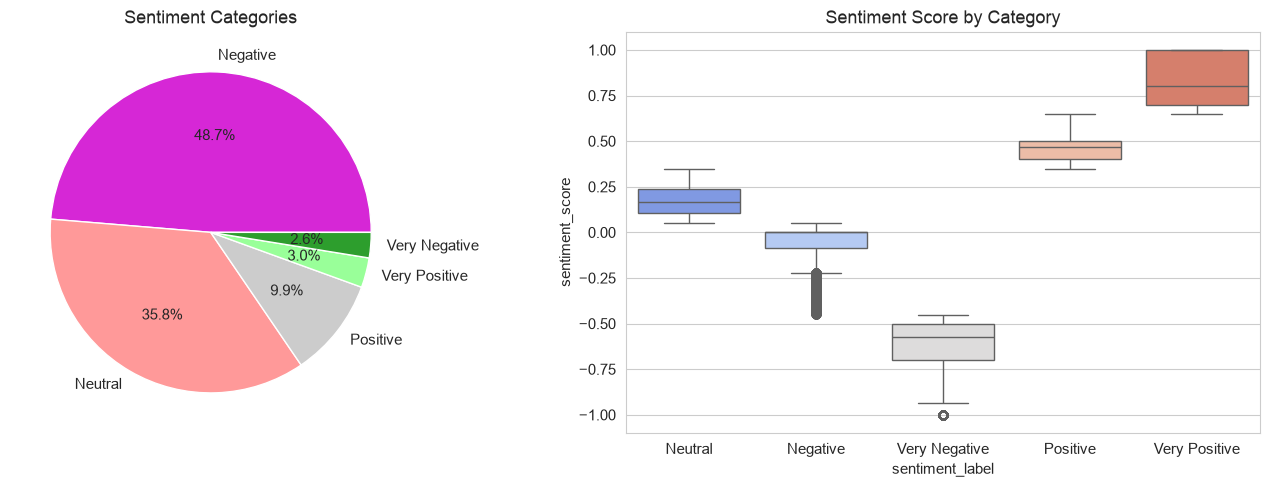

In [36]:
# Classify sentiment into categories
def sentiment_label(score):
    if score < -0.45: return 'Very Negative'
    if score < 0.05: return 'Negative'
    if score < 0.35: return 'Neutral'
    if score < 0.65: return 'Positive'
    return 'Very Positive'

df['sentiment_label'] = df['sentiment_score'].apply(sentiment_label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = df['sentiment_label'].value_counts()
colors = ['#d627d6', '#ff9999', '#cccccc', '#99ff99', '#2d9e2d']
axes[0].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', colors=colors[:len(label_counts)])
axes[0].set_title('Sentiment Categories')

sns.boxplot(data=df, x='sentiment_label', y='sentiment_score', ax=axes[1], palette='coolwarm')
axes[1].set_title('Sentiment Score by Category')

plt.tight_layout()
plt.show()

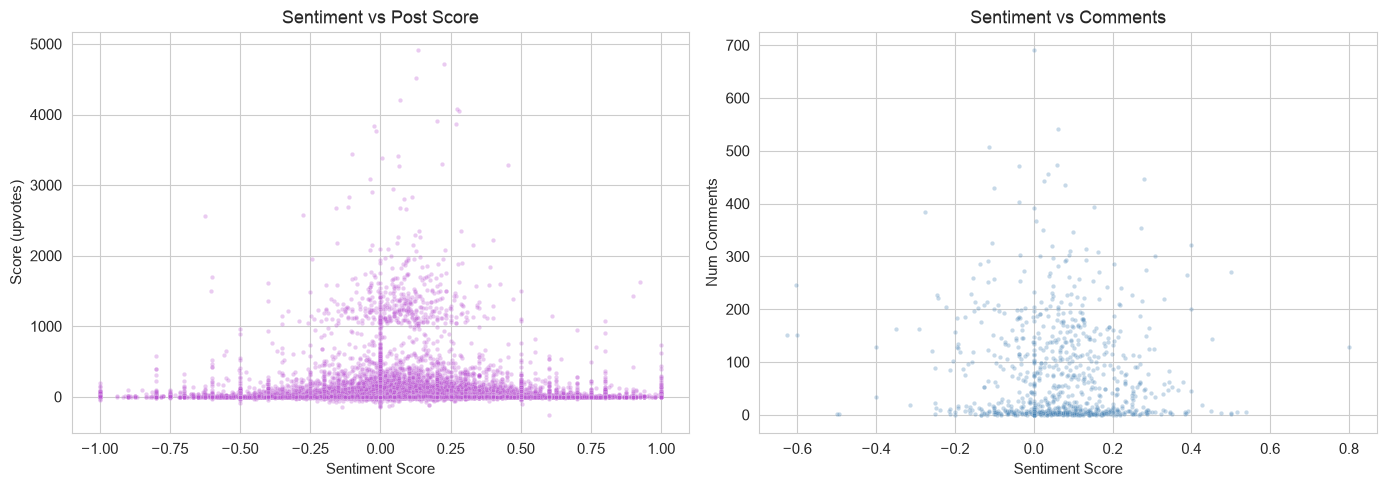

In [37]:
# Sentiment vs engagement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='sentiment_score', y='score', ax=axes[0], alpha=0.3, color='mediumorchid', s=10)
axes[0].set_title('Sentiment vs Post Score')
axes[0].set_xlabel('Sentiment Score')
axes[0].set_ylabel('Score (upvotes)')

sns.scatterplot(data=df, x='sentiment_score', y='num_comments', ax=axes[1], alpha=0.3, color='steelblue', s=10)
axes[1].set_title('Sentiment vs Comments')
axes[1].set_xlabel('Sentiment Score')
axes[1].set_ylabel('Num Comments')

plt.tight_layout()
plt.show()

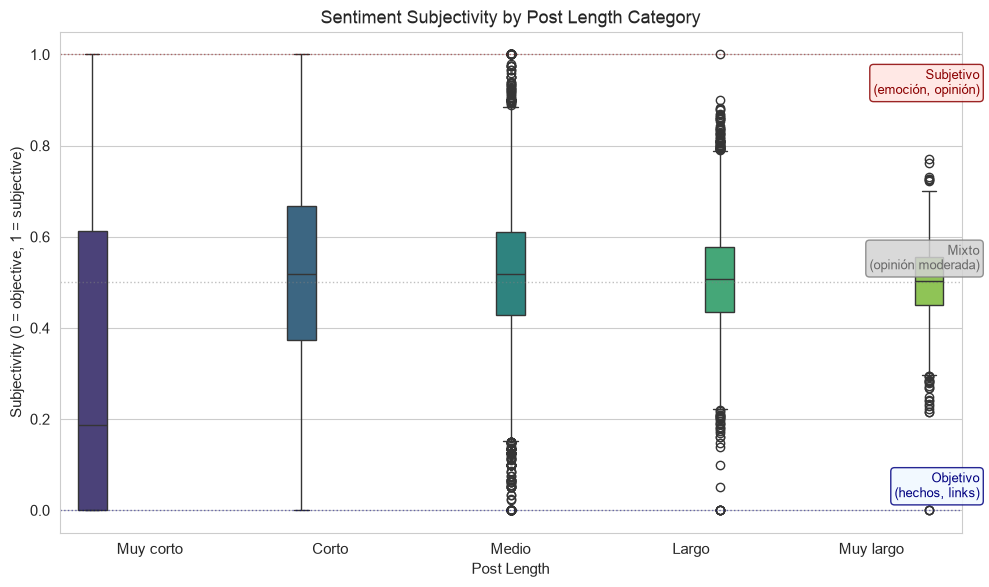

In [41]:
if 'text_length_cat' not in df.columns:
    df['text_length_cat'] = pd.cut(
        df['text_length'],
        bins=[0, 100, 300, 600, 1200, float('inf')],
        labels=['Muy corto', 'Corto', 'Medio', 'Largo', 'Muy largo'],
        include_lowest=True
    )

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='text_length_cat', y='sentiment_subjectivity',
            ax=ax, palette='viridis', hue='text_length_cat', legend=False)

ax.set_title('Sentiment Subjectivity by Post Length Category')
ax.set_xlabel('Post Length')
ax.set_ylabel('Subjectivity (0 = objective, 1 = subjective)')

# Líneas guía horizontales
ax.axhline(0.0, color='navy',    linestyle=':', alpha=0.5, linewidth=1)
ax.axhline(0.5, color='gray',    linestyle=':', alpha=0.5, linewidth=1)
ax.axhline(1.0, color='darkred', linestyle=':', alpha=0.5, linewidth=1)

# Texto al lado derecho de cada línea
x_right = len(df['text_length_cat'].cat.categories) - 0.4
ax.text(x_right, 0.02, 'Objetivo\n(hechos, links)',
        color='navy', fontsize=9, va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', fc='aliceblue', ec='navy', alpha=0.85))
ax.text(x_right, 0.52, 'Mixto\n(opinión moderada)',
        color='dimgray', fontsize=9, va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightgray', ec='gray', alpha=0.85))
ax.text(x_right, 0.97, 'Subjetivo\n(emoción, opinión)',
        color='darkred', fontsize=9, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', fc='mistyrose', ec='darkred', alpha=0.85))

plt.tight_layout()
plt.show()

## 5. Engagement Analysis

Examining how posts perform in terms of upvotes, comments, and upvote ratio. Engagement metrics are typically heavily right-skewed on Reddit.

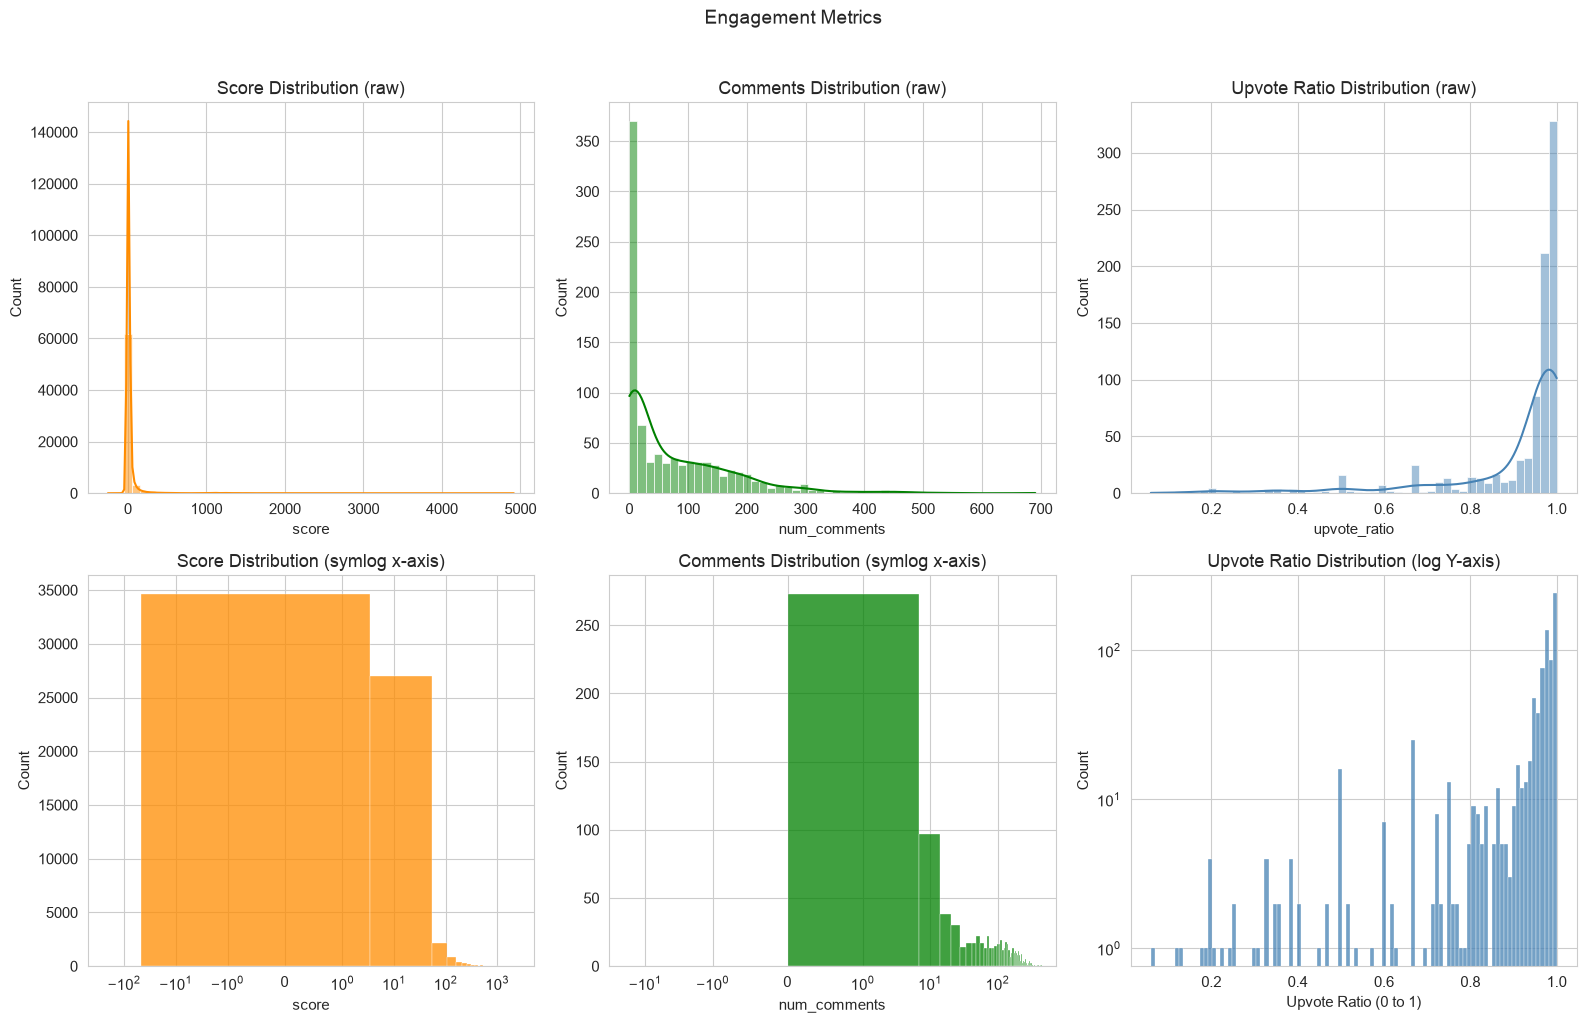

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- Fila 1: distribuciones crudas ---
sns.histplot(df['score'], bins=50, ax=axes[0,0], kde=True, color='darkorange')
axes[0,0].set_title('Score Distribution (raw)')

sns.histplot(df['num_comments'], bins=50, ax=axes[0,1], kde=True, color='green')
axes[0,1].set_title('Comments Distribution (raw)')

sns.histplot(df['upvote_ratio'], bins=50, ax=axes[0,2], kde=True, color='steelblue')
axes[0,2].set_title('Upvote Ratio Distribution (raw)')

# --- Fila 2: vistas transformadas ---
sns.histplot(df['score'], bins=100, ax=axes[1,0], color='darkorange')
axes[1,0].set_xscale('symlog', linthresh=1)
axes[1,0].set_title('Score Distribution (symlog x-axis)')

sns.histplot(df['num_comments'], bins=100, ax=axes[1,1], color='green')
axes[1,1].set_xscale('symlog', linthresh=1)
axes[1,1].set_title('Comments Distribution (symlog x-axis)')

# upvote_ratio: log en Y para ver la cola bajo el pico de 1.0
sns.histplot(df['upvote_ratio'], bins=100, ax=axes[1,2], kde=False, color='steelblue')
axes[1,2].set_yscale('log')
axes[1,2].set_title('Upvote Ratio Distribution (log Y-axis)')
axes[1,2].set_xlabel('Upvote Ratio (0 to 1)')

plt.suptitle('Engagement Metrics', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [43]:
print(f"Score: mean={df['score'].mean():.1f}, median={df['score'].median():.1f}, max={df['score'].max()}")
print(f"Comments: mean={df['num_comments'].mean():.1f}, median={df['num_comments'].median():.1f}, max={df['num_comments'].max()}")
print(f"Upvote ratio: mean={df['upvote_ratio'].mean():.3f}, median={df['upvote_ratio'].median():.3f}")

# Top 10 posts by score
top = df.nlargest(10, 'score')[['title', 'score', 'num_comments', 'upvote_ratio', 'created_date']]
print("\nTop 10 posts by score:")
top['created_date'] = top['created_date'].dt.date
top['title'] = top['title'].str[:60] + '...' 
top

Score: mean=27.6, median=3.0, max=4915
Comments: mean=74.6, median=29.0, max=691.0
Upvote ratio: mean=0.910, median=0.980

Top 10 posts by score:


,title,score,num_comments,upvote_ratio,created_date
30323,"Straight, cis male here, I just discovered a p...",4915,293.0,0.98,2022-07-21
56364,Thank you to the trans girl that gave me a tam...,4715,113.0,0.98,2021-09-11
28818,Don’t watch the new Harry Potter series on HBO...,4513,181.0,0.89,2025-05-30
12661,For anyone questioning their gender......,4211,213.0,1.00,2021-03-22
4813,UPDATE: Found a trans pride flag on my kids ph...,4075,354.0,0.99,2026-02-04
17278,r/GenderCritical is BANNED...,4053,446.0,0.92,2020-06-29
12437,My dad knows I'm trans....,3903,87.0,0.98,2019-04-04
43604,UPDATE:I caught my brother wearing my clothes ...,3869,188.0,0.97,2020-12-21
4597,"A very, very scary result from a question give...",3835,112.0,0.76,2018-10-23
13160,My mother was shamed into respecting me by my ...,3761,82.0,0.98,2025-01-13


## 6. Correlation Analysis

Identifying relationships between numeric features to understand which text characteristics are associated with engagement and sentiment.

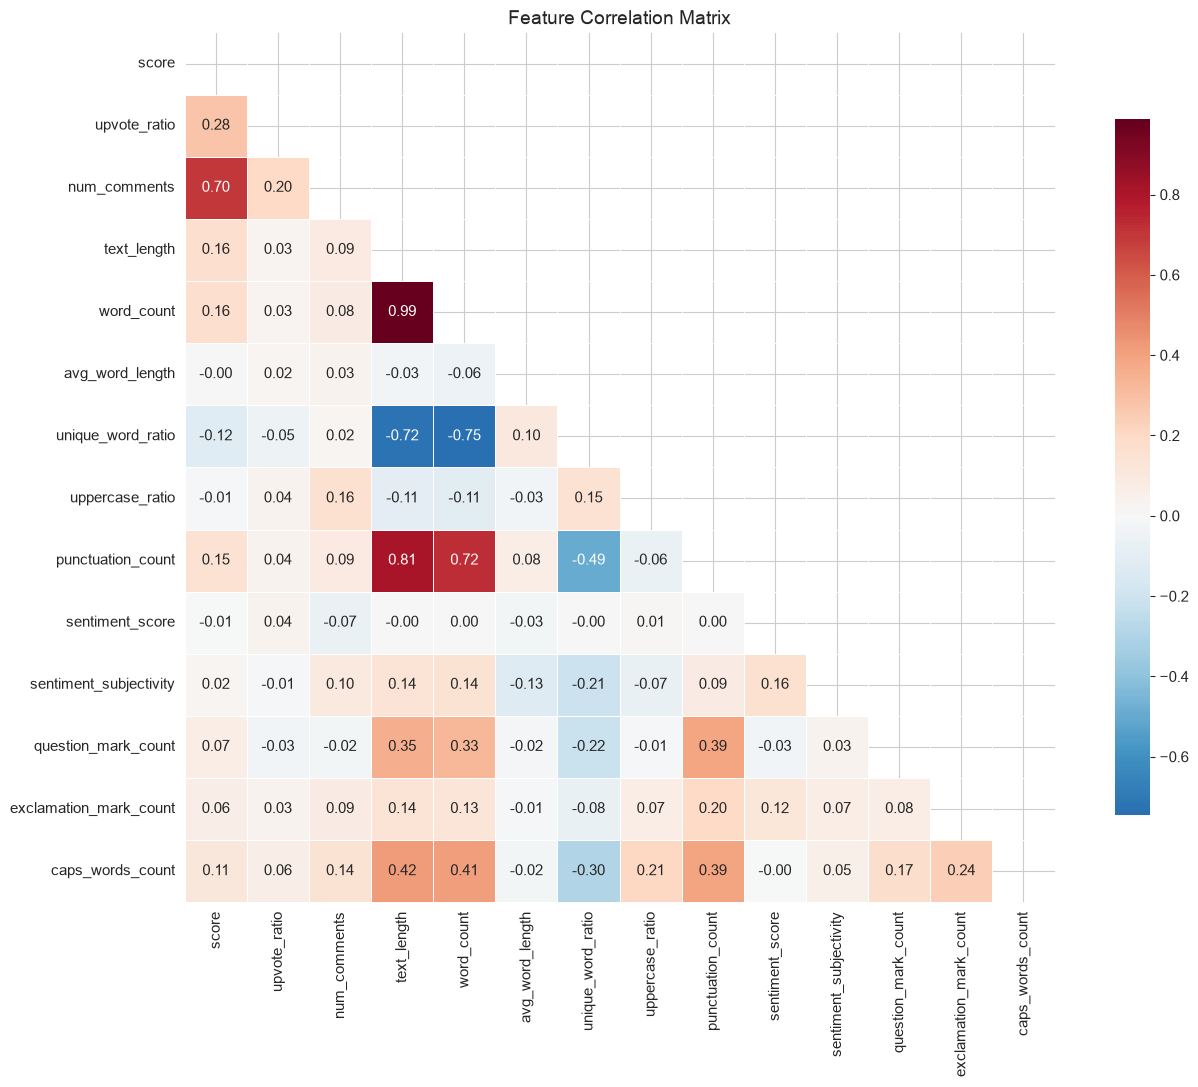

In [44]:
numeric_cols = ['score', 'upvote_ratio', 'num_comments', 'text_length', 'word_count',
                'avg_word_length', 'unique_word_ratio', 'uppercase_ratio',
                'punctuation_count', 'sentiment_score', 'sentiment_subjectivity',
                'question_mark_count', 'exclamation_mark_count', 'caps_words_count']

fig, ax = plt.subplots(figsize=(14, 11))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

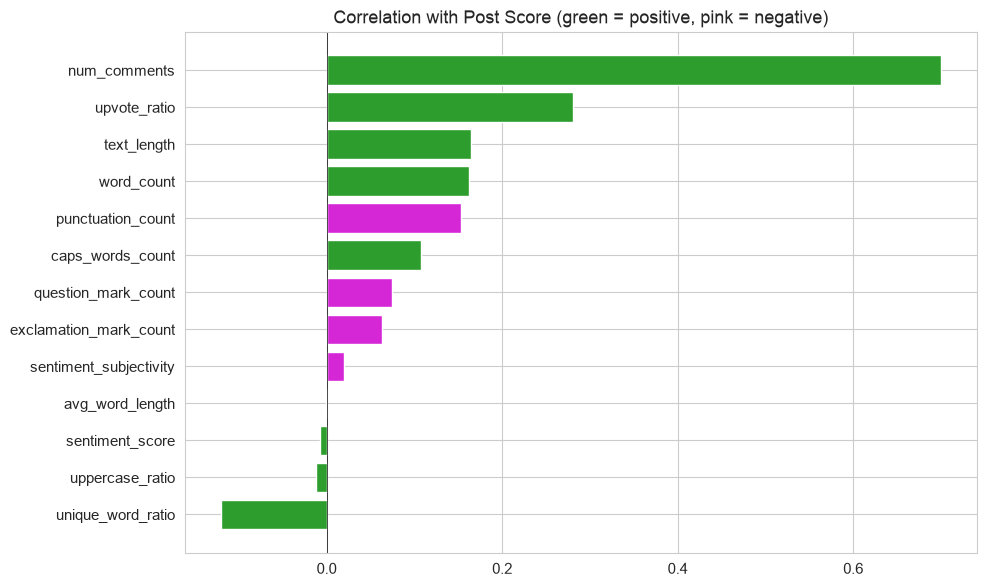

In [45]:
# Focus: what drives engagement? (correlation with score)
score_corr = corr['score'].drop('score').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2d9e2d' if v > 0 else '#d627d6' for v in corr['score'].drop('score')]
score_corr_plot = corr['score'].drop('score').sort_values()
ax.barh(range(len(score_corr_plot)), score_corr_plot.values, color=colors[:len(score_corr_plot)])
ax.set_yticks(range(len(score_corr_plot)))
ax.set_yticklabels(score_corr_plot.index)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Correlation with Post Score (green = positive, pink = negative)')
plt.tight_layout()
plt.show()

## 7. Outlier Detection

Identifying anomalous observations that may warrant further investigation.

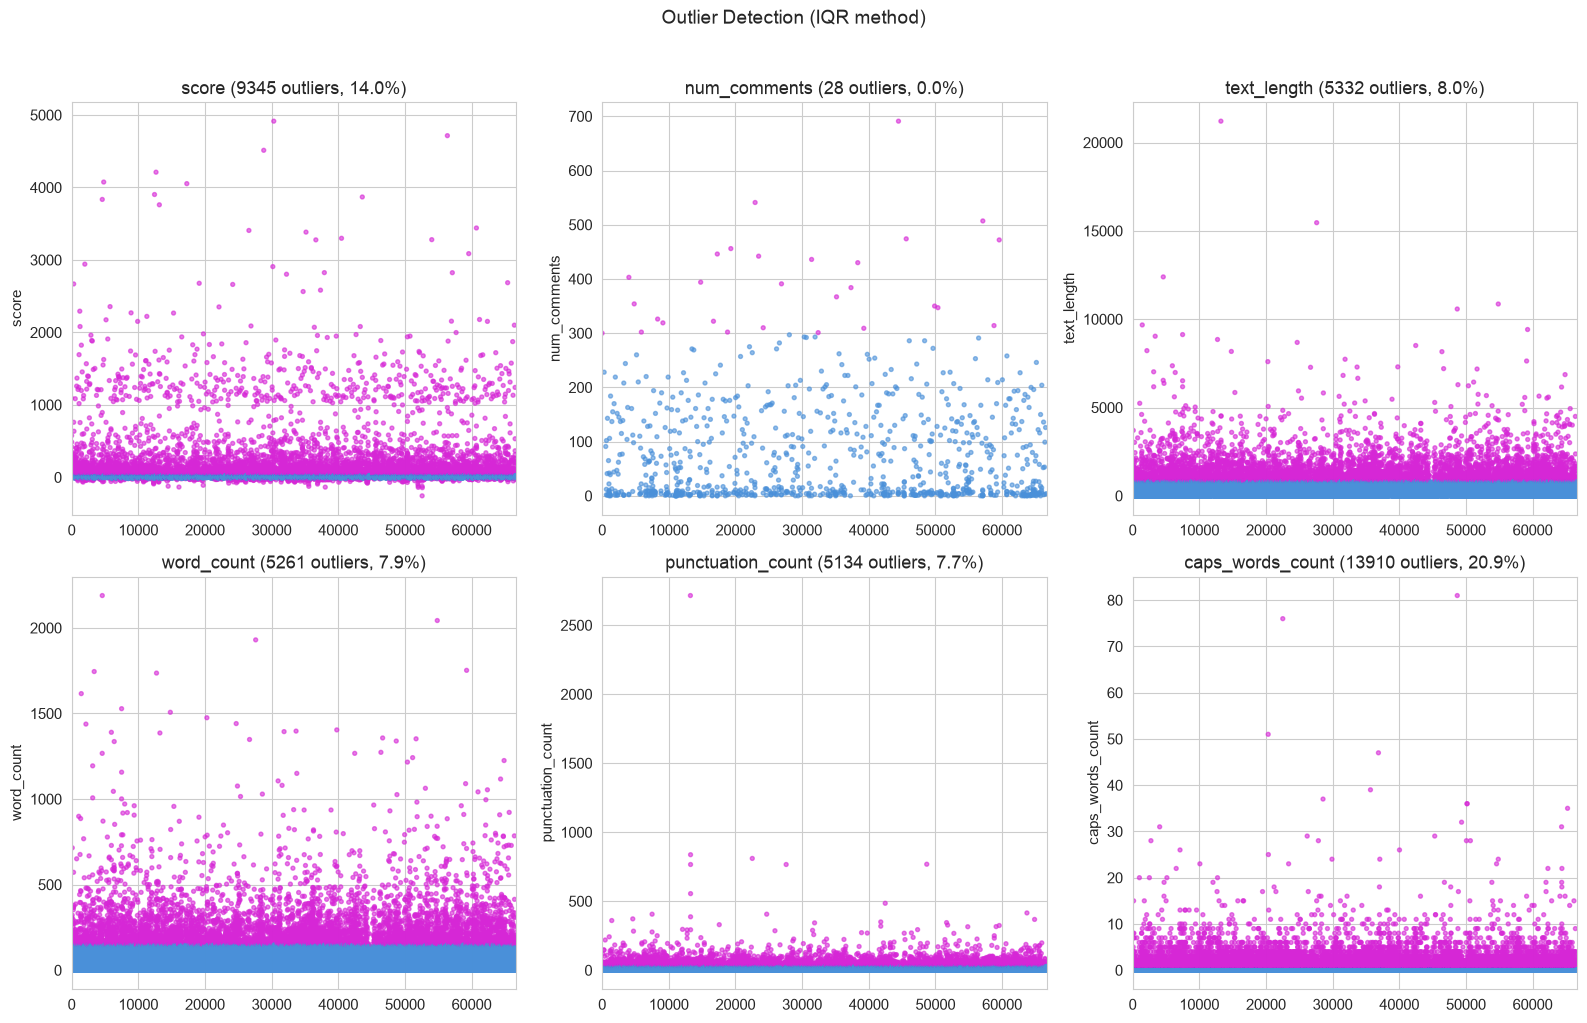

In [46]:
def outlier_mask(series, method='iqr', factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return (series < lower) | (series > upper), lower, upper

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
outlier_features = ['score', 'num_comments', 'text_length', 'word_count', 'punctuation_count', 'caps_words_count']

for ax, feat in zip(axes.flat, outlier_features):
    mask, lo, hi = outlier_mask(df[feat])
    n_out = mask.sum()
    colors = np.where(mask, '#d627d6', '#4a90d9')
    ax.scatter(df.index, df[feat], c=colors, s=8, alpha=0.6)
    ax.set_title(f'{feat} ({n_out} outliers, {n_out/len(df)*100:.1f}%)')
    ax.set_ylabel(feat)
    ax.set_xlim(-1, len(df))

plt.suptitle('Outlier Detection (IQR method)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [47]:
# Examine extreme outliers in score
mask, lo, hi = outlier_mask(df['score'])
outliers = df[mask].nlargest(10, 'score')[['title', 'score', 'num_comments', 'upvote_ratio', 'word_count', 'sentiment_score']]
outliers['title'] = outliers['title'].str[:50] + '...'

print(f"Total score outliers: {mask.sum()} / {len(df)} ({mask.sum()/len(df)*100:.1f}%)")
print(f"IQR bounds: [{lo:.0f}, {hi:.0f}]")
print("\nTop outliers:")
outliers

Total score outliers: 9345 / 66659 (14.0%)
IQR bounds: [-16, 28]

Top outliers:


,title,score,num_comments,upvote_ratio,word_count,sentiment_score
30323,"Straight, cis male here, I just discovered a p...",4915,293.0,0.98,184,0.133319
56364,Thank you to the trans girl that gave me a tam...,4715,113.0,0.98,87,0.226515
28818,Don’t watch the new Harry Potter series on HBO...,4513,181.0,0.89,228,0.126274
12661,For anyone questioning their gender......,4211,213.0,1.00,448,0.068506
4813,UPDATE: Found a trans pride flag on my kids ph...,4075,354.0,0.99,398,0.272314
17278,r/GenderCritical is BANNED...,4053,446.0,0.92,35,0.280952
12437,My dad knows I'm trans....,3903,87.0,0.98,148,0.202381
43604,UPDATE:I caught my brother wearing my clothes ...,3869,188.0,0.97,398,0.269788
4597,"A very, very scary result from a question give...",3835,112.0,0.76,2189,-0.022971
13160,My mother was shamed into respecting me by my ...,3761,82.0,0.98,145,-0.016667


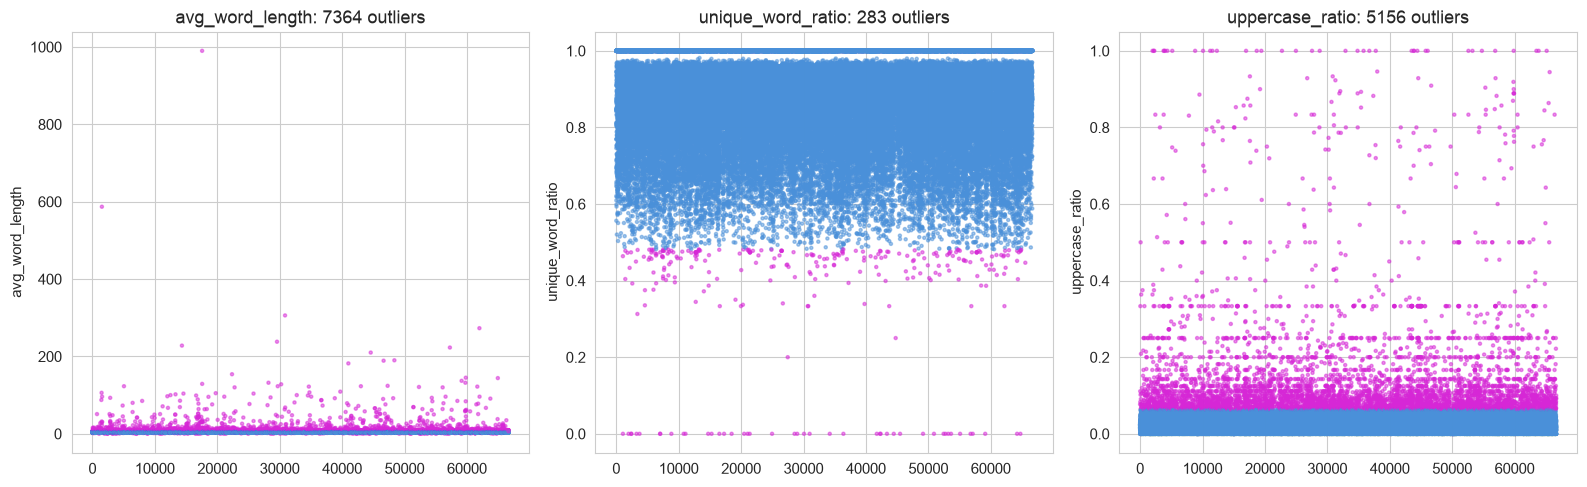

In [48]:
# Outliers in text features (potential data issues)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat in zip(axes, ['avg_word_length', 'unique_word_ratio', 'uppercase_ratio']):
    mask, lo, hi = outlier_mask(df[feat])
    colors = np.where(mask, '#d627d6', '#4a90d9')
    ax.scatter(df.index, df[feat], c=colors, s=5, alpha=0.5)
    ax.set_title(f'{feat}: {mask.sum()} outliers')
    ax.set_ylabel(feat)

plt.tight_layout()
plt.show()

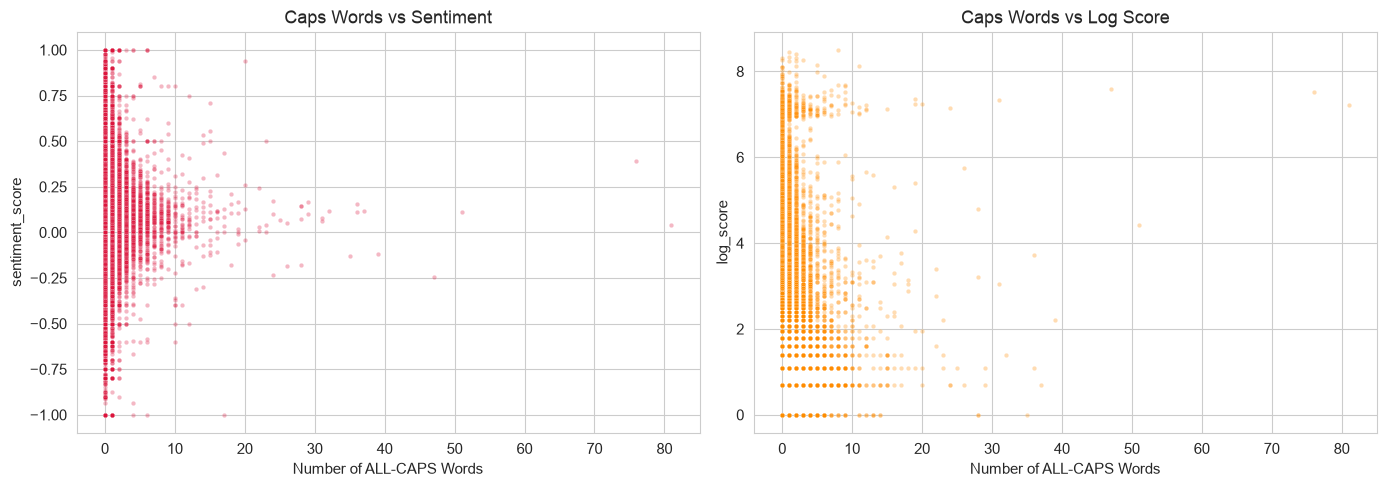

In [50]:
if 'log_score' not in df.columns:
    df['log_score'] = np.log1p(df['score'].clip(lower=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='caps_words_count', y='sentiment_score',
                ax=axes[0], alpha=0.3, s=10, color='crimson')
axes[0].set_title('Caps Words vs Sentiment')
axes[0].set_xlabel('Number of ALL-CAPS Words')

sns.scatterplot(data=df, x='caps_words_count', y='log_score',
                ax=axes[1], alpha=0.3, s=10, color='darkorange')
axes[1].set_title('Caps Words vs Log Score')
axes[1].set_xlabel('Number of ALL-CAPS Words')

plt.tight_layout()
plt.show()

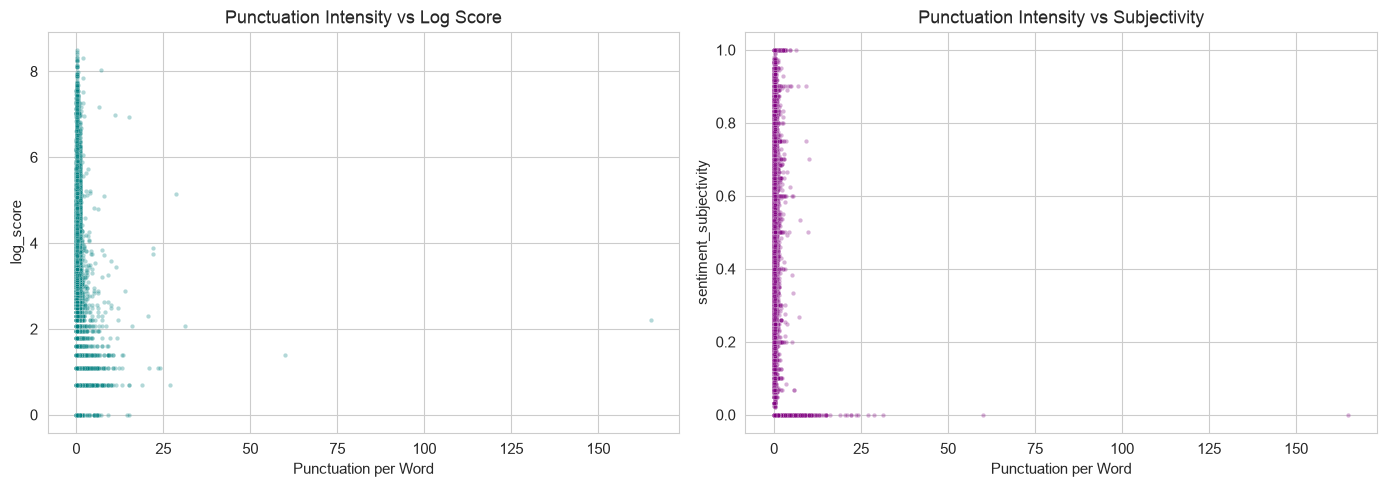

In [51]:
# Punctuation intensity vs engagement
df['punct_intensity'] = df['punctuation_count'] / (df['word_count'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='punct_intensity', y='log_score', ax=axes[0], alpha=0.3, s=10, color='teal')
axes[0].set_title('Punctuation Intensity vs Log Score')
axes[0].set_xlabel('Punctuation per Word')

sns.scatterplot(data=df, x='punct_intensity', y='sentiment_subjectivity', ax=axes[1], alpha=0.3, s=10, color='purple')
axes[1].set_title('Punctuation Intensity vs Subjectivity')
axes[1].set_xlabel('Punctuation per Word')

plt.tight_layout()
plt.show()

## 9. Suggested Subreddits

Analyzing which subreddits are most commonly suggested for crossposting, and how suggested posts differ from non-suggested ones.

Comentarios totales: 65778
Comentarios con al menos 1 sub sugerido: 1126 / 65778 (1.7%)
Total de menciones de subs: 1647
Subs únicos: 365


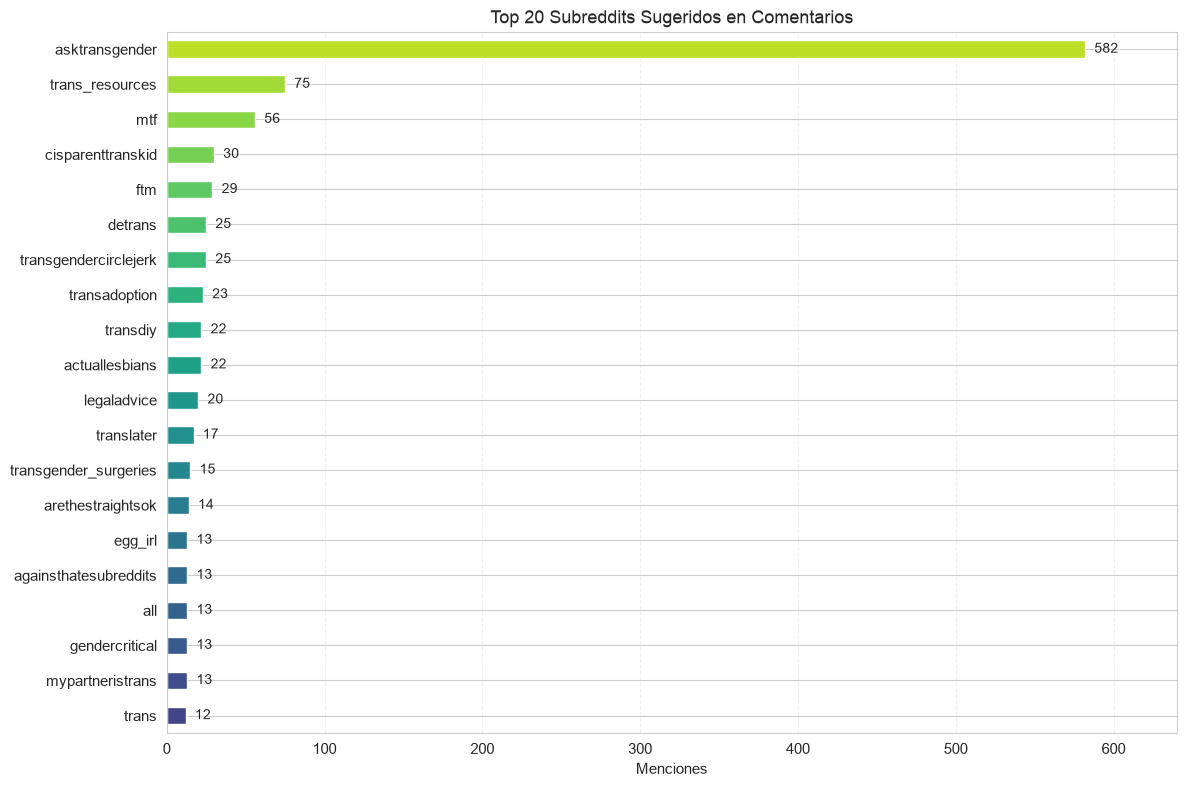

In [52]:
import ast
from collections import Counter

def parse_subreddits(val):
    """Convierte '[]' o "['r/trans', 'r/MtF']" en una lista limpia."""
    if pd.isna(val):
        return []
    try:
        items = val if isinstance(val, list) else ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return []
    
    cleaned = []
    for s in items:
        s = str(s).strip().lower()
        if s.startswith('r/'):
            s = s[2:]
        if s:
            cleaned.append(s)
    return cleaned

# --- Filtrar SOLO comentarios ---
comments = df[df['type'] == 'comment'].copy()

subs_list = comments['suggested_subreddit'].apply(parse_subreddits)
all_subs = [sub for lst in subs_list for sub in lst]

print(f"Comentarios totales: {len(comments)}")
print(f"Comentarios con al menos 1 sub sugerido: {(subs_list.str.len() > 0).sum()} / {len(comments)} "
      f"({(subs_list.str.len() > 0).mean()*100:.1f}%)")
print(f"Total de menciones de subs: {len(all_subs)}")
print(f"Subs únicos: {len(set(all_subs))}")

# Top 20
top_subs = pd.Series(Counter(all_subs)).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))

top_subs_sorted = top_subs.sort_values()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_subs_sorted)))
top_subs_sorted.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title(f'Top {len(top_subs)} Subreddits Sugeridos en Comentarios', fontsize=13)
ax.set_xlabel('Menciones')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Etiquetas con el conteo al final de cada barra
for i, (name, val) in enumerate(top_subs_sorted.items()):
    ax.text(val + max(top_subs)*0.01, i, str(val),
            va='center', fontsize=10)

# Margen extra a la derecha para que las etiquetas no se corten
ax.set_xlim(0, max(top_subs) * 1.10)

plt.tight_layout()
plt.show()

Top 100 posts: 12 tienen al menos 1 sub sugerido / 100
Total de menciones: 167
Subs únicos: 137


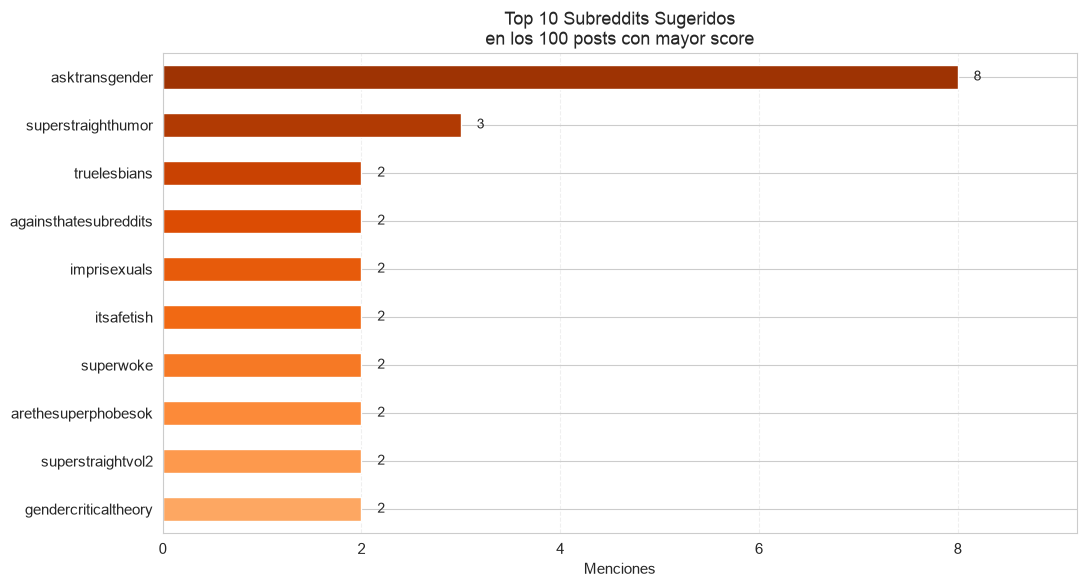

In [53]:
# Top 100 posts por score
top_100 = df.nlargest(100, 'score')

# Reutilizamos parse_subreddits (ya definida antes en el notebook)
subs_top100 = top_100['suggested_subreddit'].apply(parse_subreddits)
all_subs_top100 = [sub for lst in subs_top100 for sub in lst]

# Cuántos posts del top 100 tienen al menos 1 sugerencia real
n_with = (subs_top100.str.len() > 0).sum()
print(f"Top 100 posts: {n_with} tienen al menos 1 sub sugerido / {len(top_100)}")
print(f"Total de menciones: {len(all_subs_top100)}")
print(f"Subs únicos: {len(set(all_subs_top100))}")

# Top 10 subs en el top 100
top_subs_100 = pd.Series(Counter(all_subs_top100)).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))

top_subs_100_sorted = top_subs_100.sort_values()
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(top_subs_100_sorted)))
top_subs_100_sorted.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title(f'Top {len(top_subs_100)} Subreddits Sugeridos\n'
             f'en los 100 posts con mayor score',
             fontsize=13)
ax.set_xlabel('Menciones')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Etiquetas con el conteo
for i, (name, val) in enumerate(top_subs_100_sorted.items()):
    ax.text(val + max(top_subs_100)*0.02, i, str(val), va='center', fontsize=10)

ax.set_xlim(0, max(top_subs_100) * 1.15)

plt.tight_layout()
plt.show()

## 10. Key Findings & Summary

### Data Overview

### Temporal Patterns

### Text Features

### Sentiment

### Engagement

### Outliers

### Suggested Subreddits

